In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("data/raw/Super store Sales.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Convert Order Date to Datetime

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)


Check Dataset Shape

In [4]:
df.shape


(9800, 18)

Missing Values Check (COUNT)

In [5]:
df.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Missing Values Check (PERCENTAGE)

In [6]:
(df.isnull().mean() * 100).sort_values(ascending=False)


Postal Code      0.112245
Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Mode        0.000000
Ship Date        0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
Customer ID      0.000000
City             0.000000
State            0.000000
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64

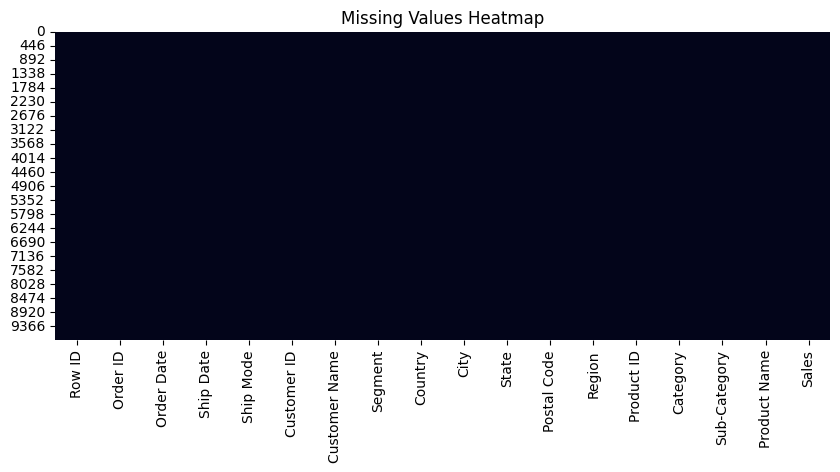

In [7]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [8]:
df["Postal Code"] = df["Postal Code"].fillna("Unknown")

In [9]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

Sort Data by Date

In [10]:
df = df.sort_values("Order Date")


Monthly Sales Aggregation

In [11]:
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()


C:\Users\K ADITHYA\AppData\Local\Temp\ipykernel_18400\2601079036.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Monthly Sales Trend

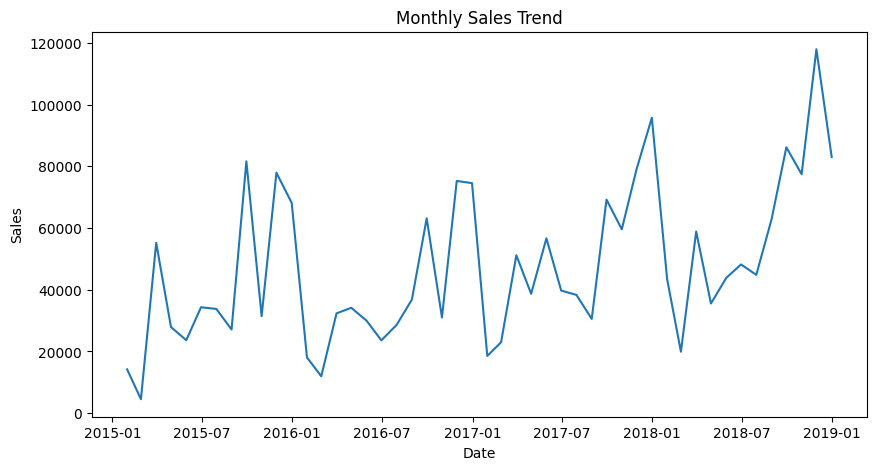

In [12]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


Sales show temporal variation with visible seasonality

Monthly aggregation smooths daily noise

Category-wise Sales

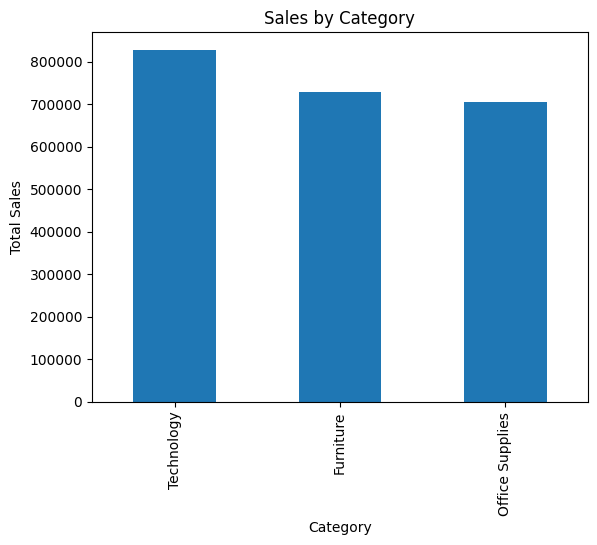

In [13]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar", title="Sales by Category")
plt.ylabel("Total Sales")
plt.show()


Region-wise Sales

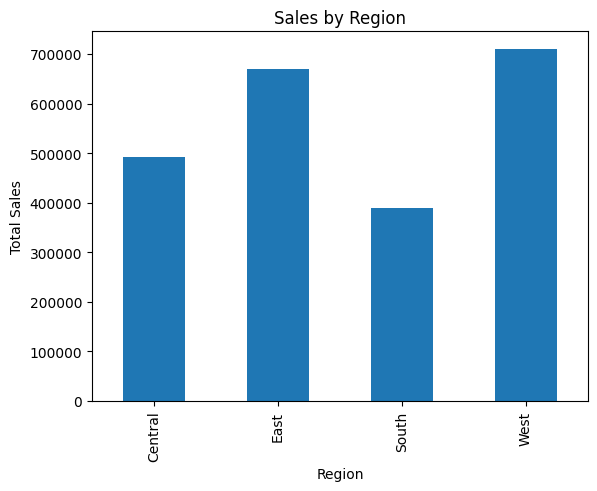

In [14]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar", title="Sales by Region")
plt.ylabel("Total Sales")
plt.show()


Sub-Category-wise Sales

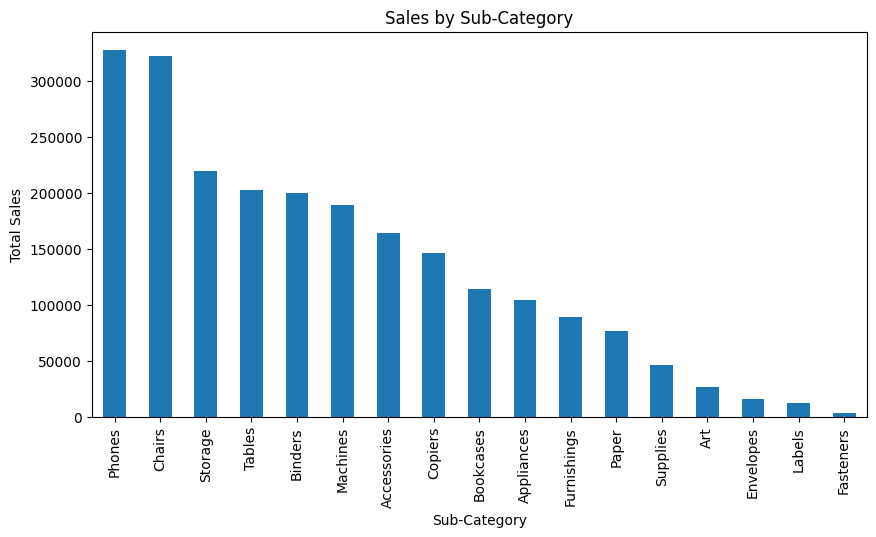

In [15]:
sub_category_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sub_category_sales.plot(kind="bar", figsize=(10,5), title="Sales by Sub-Category")
plt.ylabel("Total Sales")
plt.show()


Segment-wise Sales

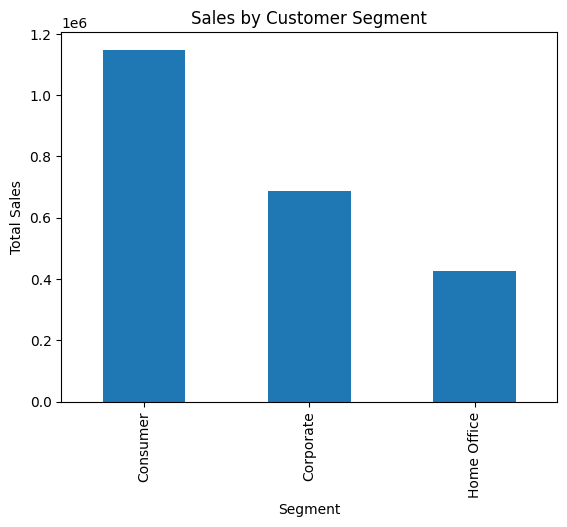

In [16]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="bar", title="Sales by Customer Segment")
plt.ylabel("Total Sales")
plt.show()


EDA Summary

Key Insights

Sales exhibit seasonal trends when aggregated monthly

Certain categories and sub-categories dominate revenue

Regional sales distribution is uneven

Consumer segment contributes the highest sales

Dataset is well-suited for time-series forecasting